In [15]:
import numpy as np
import matplotlib.pyplot as plt
import time
import random
from collections import deque
from tqdm import tqdm
import pandas as pd
import copy

In [16]:
P_0_matrix=np.array([[0.5,0,0,0.5],
                   [0.5,0.5,0,0],
                   [0,0.5,0.5,0],
                   [0,0,0.5,0.5]])


In [17]:
P_1_matrix=P_0_matrix.transpose()

In [18]:
action_space=[0,1]
state_space=[0,1,2,3]
reward_matrix=[-1,0,0,1]

In [19]:
def step(state,state_space,action,P_0_matrix,P_1_matrix,reward_matrix):
  new_state=state
  if(action==1):
    new_state=np.random.choice(state_space,replace=True,p=P_1_matrix[state])
    reward=reward_matrix[state]
  else:
    new_state=np.random.choice(state_space,replace=True,p=P_0_matrix[state])
    reward=reward_matrix[state]
  return [new_state,reward]

In [20]:
N=100
M=20
epsilon=1
subsidy=0
arm_indexes=[i for i in range(N)]
gamma=0.99

In [21]:
Q_values=[]
for i in range(N):
  Q_values.append([[-1,-1],[0,0],[0,0],[1,1]])

In [ ]:
Q_values

In [22]:
def Q_value_update(Q_values,state,next_state,action,reward,arm_index,subsidy,alpha):
  if action==1:
    Q_values[arm_index][state][action]=(1-alpha)*(Q_values[arm_index][state][action])+alpha*(reward+max(Q_values[arm_index][next_state])-(np.array(Q_values[arm_index]).sum())/8)
  else:
    Q_values[arm_index][state][action]=(1-alpha)*(Q_values[arm_index][state][action])+alpha*(reward+subsidy+max(Q_values[arm_index][next_state])-(np.array(Q_values[arm_index]).sum())/8)




In [23]:
def act(Q_values,epsilon,state,arm_index):
  decision=np.random.binomial(n=1,p=epsilon,size=1)
  if decision==1:
    action=random.choice([0,1])
  else:
    action=np.argmax(Q_values[arm_index][state])
  return action



In [24]:
current_state=[0 for _ in range(N)]

In [25]:
whittle_indexes=[]
for _ in range(N):
    whittle_indexes.append([0 for _ in range(len(state_space))])
whittle_indexes

[[0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0, 0],
 [0, 0, 0,

In [26]:
rewards=[]
subsidies=[]
action_sums=[]
betas=[]
alphas=[]
whittle_indexes_over_time=[]
whittle_indexes_over_time.append(copy.deepcopy(whittle_indexes))
whittle_indexes_over_time

[[[0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0, 0, 0],
  [0, 0,

In [27]:
for i in range(1,20001):
    # top_M_indices=act(alternative_indexes,N,M,epsilon)
    action_sum=0
    reward_sum=0
    alpha=1/(1+(i/10000))
    beta=1/(1+np.ceil(i*np.log(i)/10000))
    epsilon=0.1
    temp=0
    for index in arm_indexes:
        # action=np.argmax(Q_values[index][current_state[index]])
        action=act(Q_values,epsilon,current_state[index],index)
        action_sum+=action
        x=step(current_state[index],state_space,action,P_0_matrix,P_1_matrix,reward_matrix)
        new_state=x[0]
        reward=x[1]
        temp=Q_values[index][current_state[index]][1]-Q_values[index][current_state[index]][0]
        Q_value_update(Q_values,current_state[index],new_state,action,reward,index,whittle_indexes[index][current_state[index]],alpha)

        whittle_indexes[index][current_state[index]]+=beta*temp
        current_state[index]=new_state
        reward_sum+=reward

    whittle_indexes_over_time.append(copy.deepcopy(whittle_indexes))
    rewards.append(reward_sum)
    action_sums.append(action_sum)
    betas.append(beta)
    alphas.append(alpha)








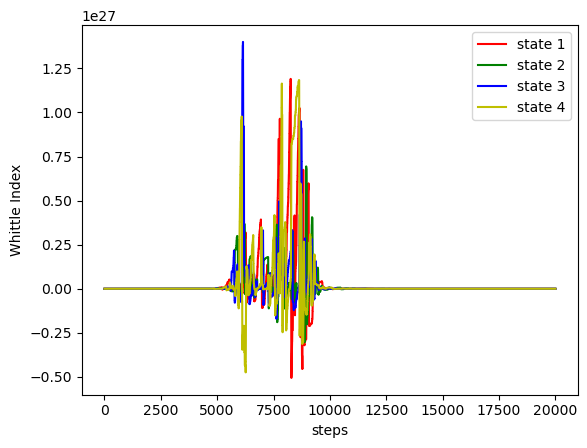

In [28]:
t=20000
j=2
state1=[whittle_indexes_over_time[i][j][0] for i in range(t)]
state2=[whittle_indexes_over_time[i][j][1] for i in range(t)]
state3=[whittle_indexes_over_time[i][j][2] for i in range(t)]
state4=[whittle_indexes_over_time[i][j][3] for i in range(t)]
plt.figure()
plt.plot(state1,color='r',label='state 1')
plt.plot(state2,color='g',label='state 2')
plt.plot(state3,color='b',label='state 3')
plt.plot(state4,color='y',label='state 4')
plt.legend()
plt.ylabel('Whittle Index')
plt.xlabel('steps')
plt.show()


In [31]:
Q_values

[[[481734238286354.25, 424565806522978.4],
  [377785132504289.9, 202456803393313.7],
  [68900404813982.695, 47102961062994.78],
  [-198379986349282.12, 184396166113467.5]],
 [[1.0082062935479314e+17, 1.1835565028758646e+17],
  [3.502615660849494e+16, 4.712508515808964e+16],
  [7.1051243943590856e+16, 7.713679440146882e+16],
  [-1.4399492507074675e+17, 9.444640897588387e+16]],
 [[-4787430505641.024, 6158955877781.682],
  [59112526261442.12, 3599410315295.497],
  [324040394524.30493, 3624584557982.3867],
  [593145325893.364, 3944504048178.4854]],
 [[4.922304884974145e+17, 1.9644443026923328e+17],
  [-1.1730764325458656e+16, -2.0738157723609376e+17],
  [-3.4708295346973944e+16, 2.8045925024435546e+17],
  [6.955455469285196e+17, 4.124702990012155e+17]],
 [[-7.81359838306673e+16, 1.575577064075418e+17],
  [4.120042619237508e+17, 1.1941190662403154e+17],
  [1.498532837905902e+17, 6.585208227791142e+16],
  [2.5012255442657612e+16, 6.511076154474246e+16]],
 [[-4.357451299178787e+16, -5.7545507